# Le distribuzioni di Poisson

Consideriamo un esperimento binomiale nel quale il numero $n$ di ripetizioni
è elevato. Questo fatto non cambia la validità delle formule che descrivono
la distribuzione della variabile aleatoria $X \sim \mathrm B(n, p)$ che
conteggia il numero di successi. Consideriamo però il codice che ho introdotto
nel {numref}`Paragrafo %s <sec:binomial-quantiles>` per il calcolo dei
quantili, e che riporto qui di seguito per comodità.

```python
from scipy.special import binom

def quantiles(n, p, levels):
    x = 0

    pdf = (1-p)**n
    cdf = pdf
    quantiles = []

    for q in levels:
        while cdf < q:
            pdf *= (n - x) / (x + 1) * p / (1 - p)
            cdf += pdf
            x += 1
        quantiles.append(x)

    return quantiles
```

Nel corpo della funzione `quantiles`, la variabile `pdf` viene inizializzata
al valore che corrisponde a $(1 - p)^n$. Ora, se $n$ assume un valore elevato.
diciamo dell'ordine delle decine di migliaia, indipendentemente dal valore di
$p$ è ragionevole il risutato del calcolo della potenza venga memorizzato come
$0$, tenendo conto della precisione dei numeri in virgola mobile. Analoghe
considerazioni valgono per esempio per il calcolo della funzione di massa di
probabilità. In casi come questo, se il valore elevato di $n$ è in qualche
modo controbilanciato da un valore basso di $p$, è possibile introdurre una
nuova famiglia di distribuzioni che permette di approssimare quella di $X$.

In particolare, fissato $\lambda \in \mathbb R^+$ consideriamo una successione
di variabili aleatorie $X_1, X_2, \dots$, dove per ogni $n \in \mathbb N$ si
ha $X_n \sim \mathrm B(n, p_n)$ e $n p_n = \lambda$. La funzione di massa di
probabilità di una generica variabile di questa successione è tale che

```{math}
f_{X_n}(x; n, p_n) = \binom{n}{x} p_n^x (1-p_n)^{n-x} \enspace.
```

Per analizzare il generico andamento di questa funzione, vale la pena
studiare il rapporto $\rho$ tra i valori che essa assume per due valori
successivi della relativa specificazione:

```{math}
\rho = \frac{f_X(x+1; \lambda)}{f_X(x; \lambda)}
     = \mathrm e^{-\lambda} \frac{\lambda^x}{x!}
       \mathrm e^\lambda \frac{\lambda^{x+1}}{(x+1)!}
     = \frac{\lambda}{x + 1} \enspace,
```

così che:

- $\rho > 1$, e quindi $f_X(x+1; \lambda) > f_X(x; \lambda)$,
  se e solo se $x < \lambda - 1$,
- $\rho = 1$, che equivale a $f_X(x+1; \lambda) = f_X(x; \lambda)$,
  se e solo se $x = \lambda - 1$,
- $\rho < 1$ nei casi rimanenti.

Tenuto conto del fatto che le specificazioni $x$ assumono valori interi non
negativi, da queste relazioni si ricava che in funzione di $\lambda$ si hanno
tre differenti situazioni possibili, illustrate anche nella
{numref}`Figura $s <fig:poisson-pmfs>`:

- se $\lambda \not\in \mathbb N$ e $\lambda < 1$, $f_X(0; \lambda)$
  rappresenta il massimo valore di massa di probabilità, la relativa funzione
  è strettamente decrescente e $0$ è la moda della distribuzione;
- quando $\lambda \not\in \mathbb N$ ma $\lambda > 1$, la funzione di massa di
  probabilità è inizialmente crescente e ha un massimo nel valore modale
  $\lceil \lambda \rceil$, poi decresce;
- quando $\lambda \in \mathbb N$ la situazione è simile al punto precedente,
  ma in questo caso vi sono due valori modali: $\lambda - 1$ e $\lambda$.

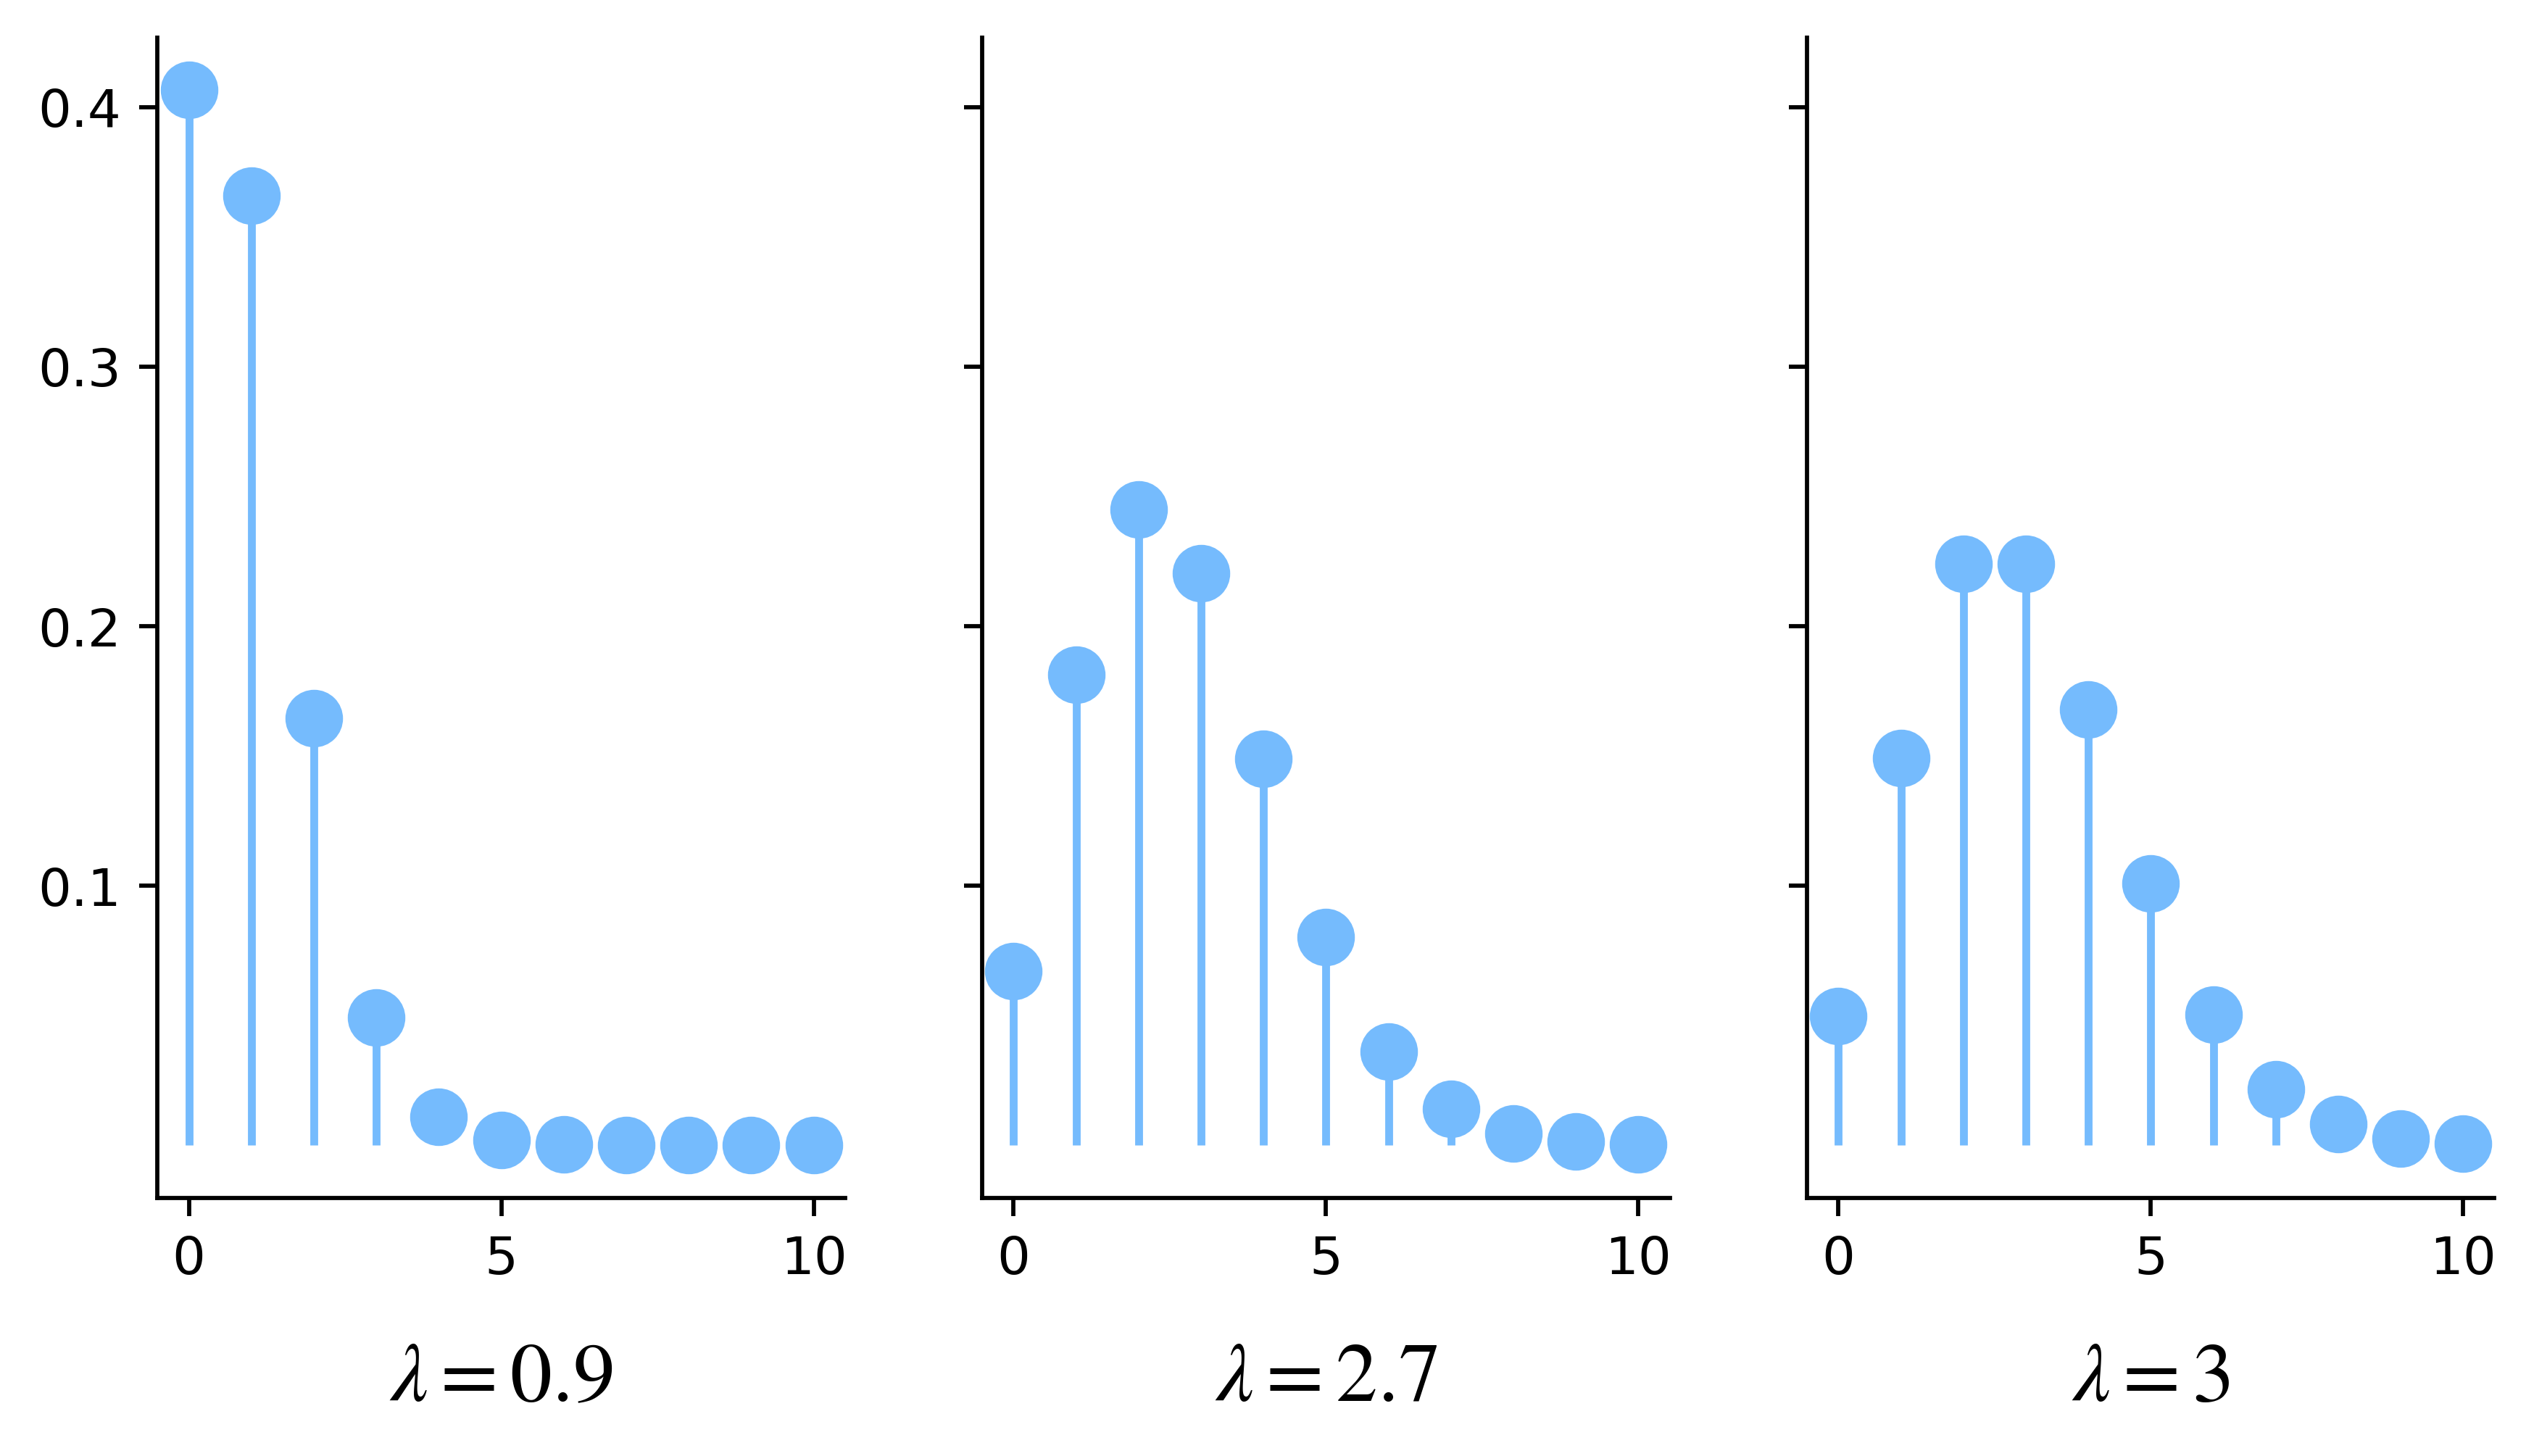

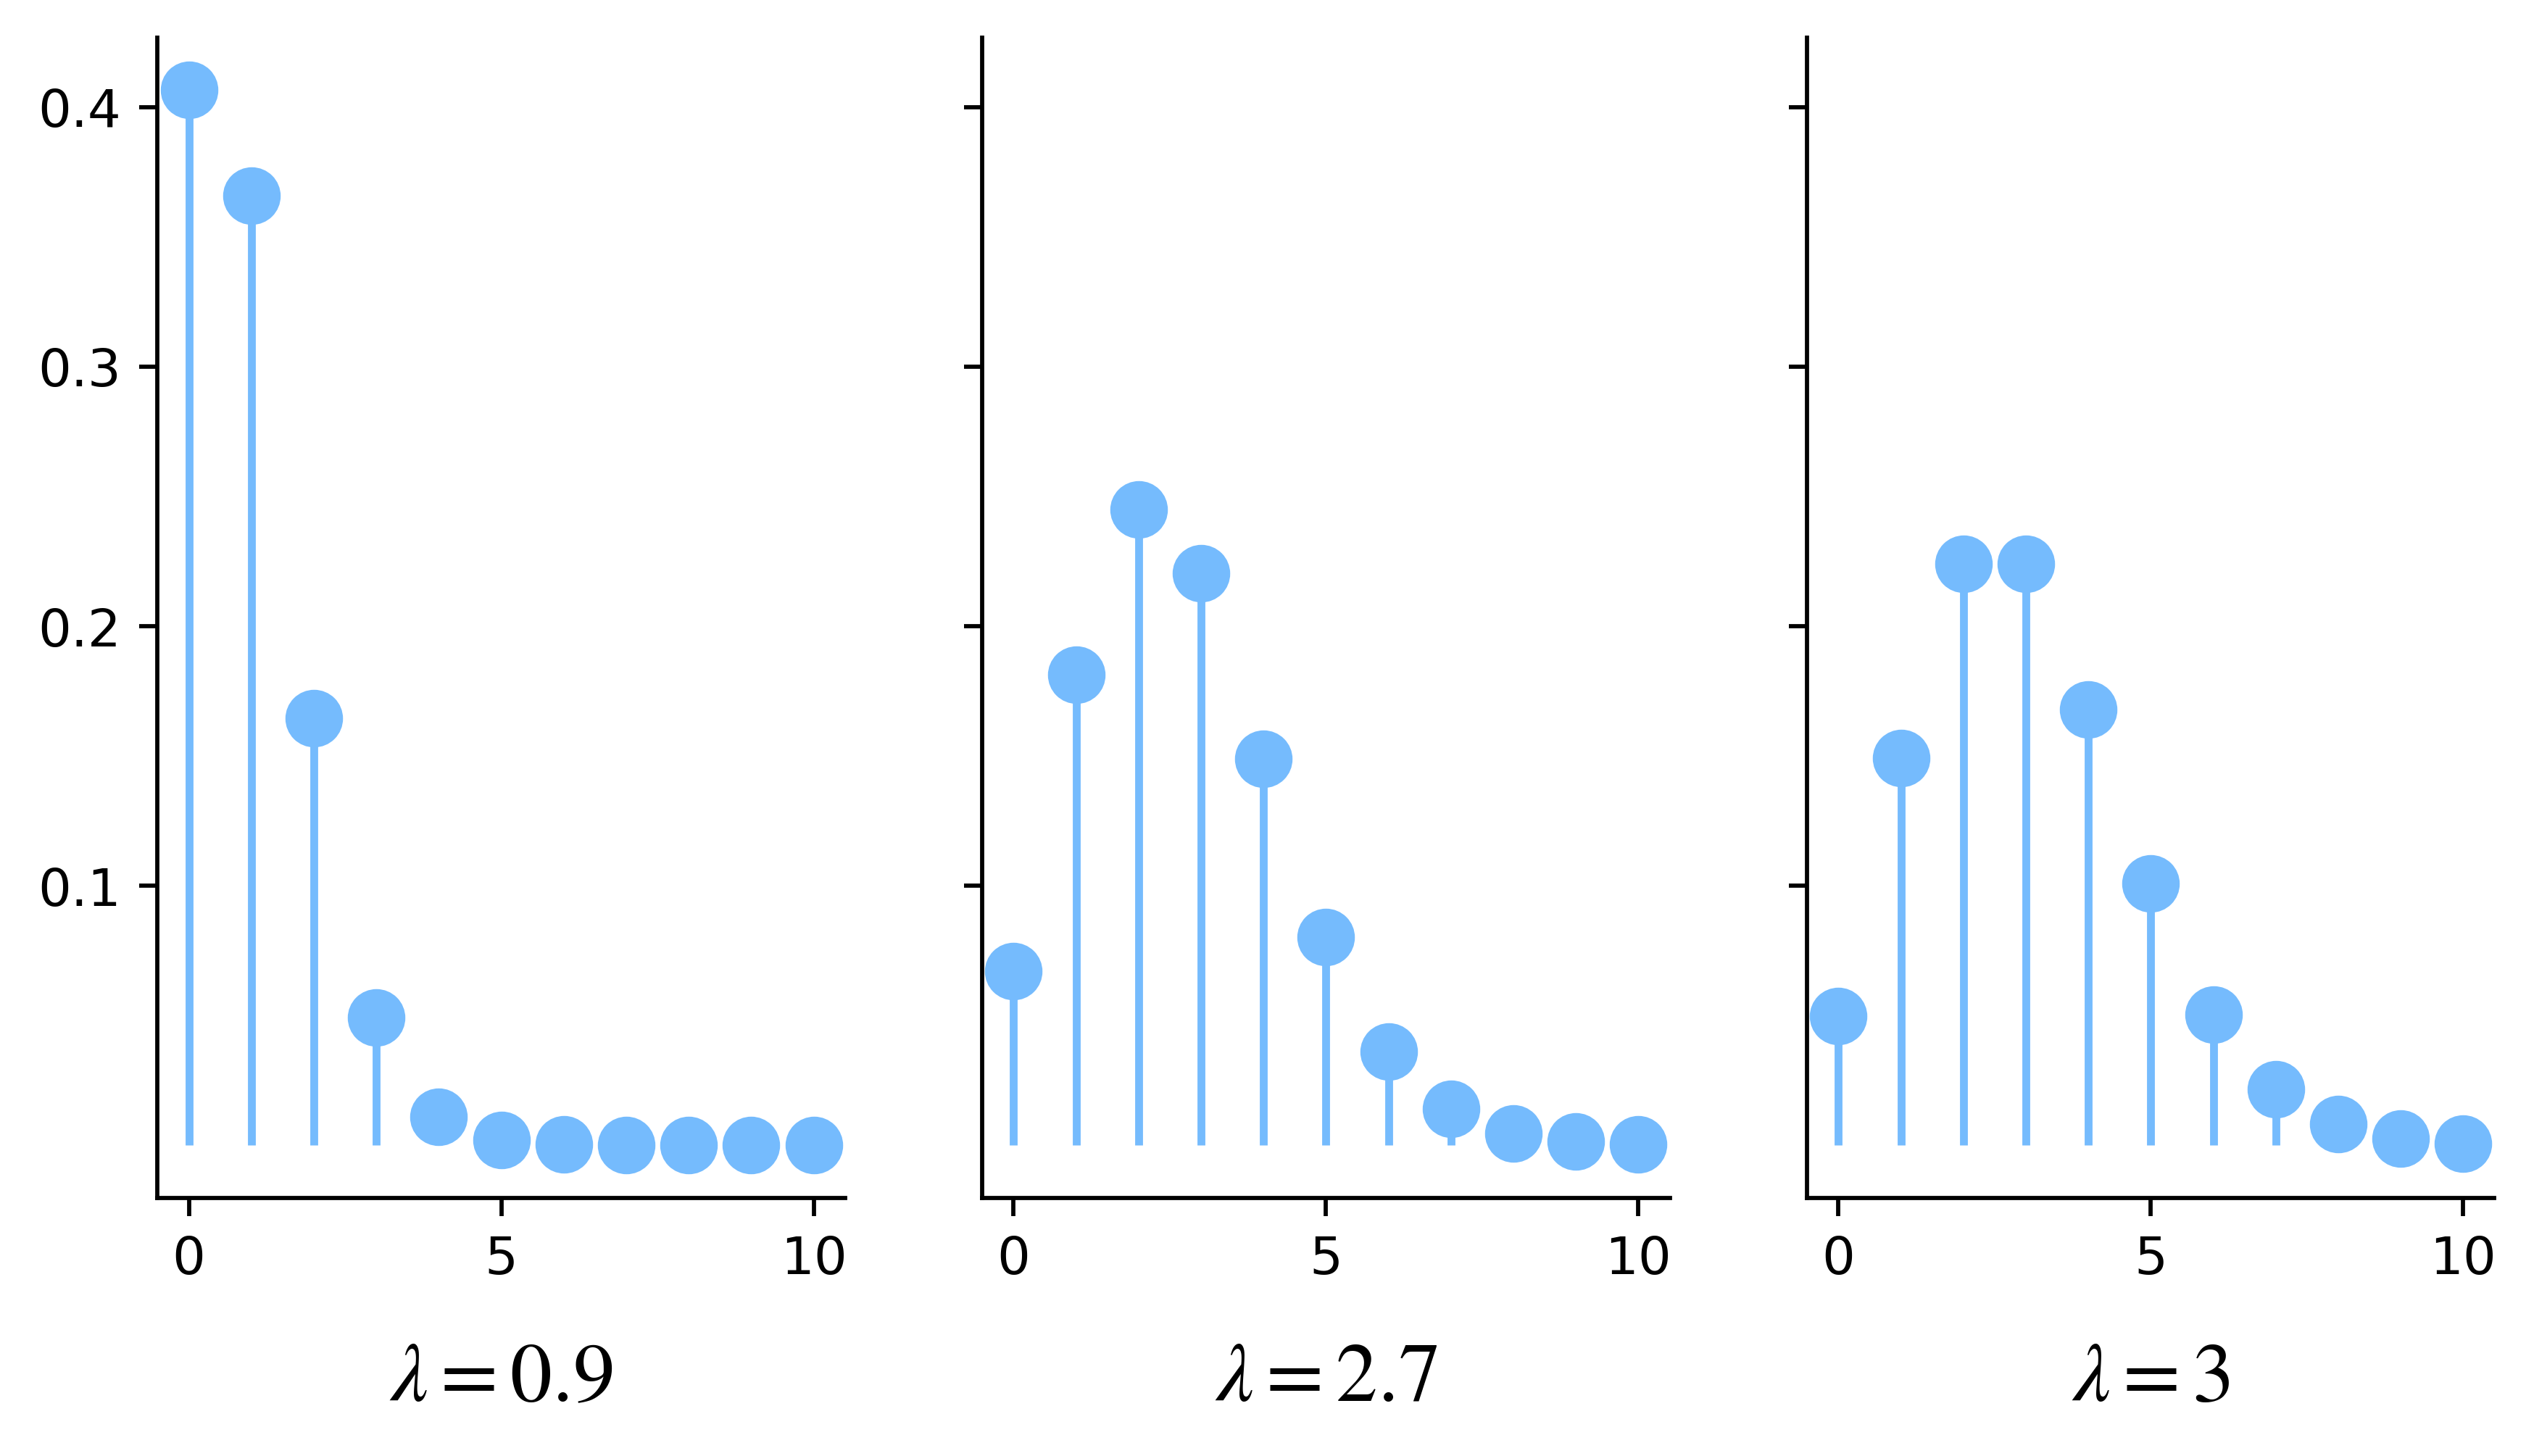

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as st

from myst_nb import glue

def poisson_graph(lambda_, ax):
    n = 10
    x = np.arange(0, n+1)

    X = st.poisson(lambda_)
    ax.vlines(x, 0, X.pmf(x))
    ax.plot(x, X.pmf(x), 'o')

fig, axes = plt.subplots(1, 3, sharey=True, figsize=(8, 4))
for lambda_, ax in zip([0.9, 2.7, 3], axes):
    poisson_graph(lambda_, ax)
    ax.set_yticks([0.1, 0.2, 0.3, 0.4])
    ax.set_xlabel(rf'$\lambda = {lambda_!r}$')
plt.show()

glue("poisson-pmfs", fig, display=True)

```{glue:figure} poisson-pmfs
:figwidth: 400pt
:name: "fig:poisson-pmfs"

Grafici della funzione di massa di probabilità per le distribuzioni di
Poisson di parametro $0.9$ (sinistra), $2.7$ (centro) e $3$ (destra).
```




## Momenti della distribuzione di Poisson (*)

La funzione generatrice dei momenti di una generica distribuzione di Poisson
ha una particolare forma, nella quale compare un doppio elevamento a potenza,
come ottenuto nel seguente risultato.

```{margin}
Nella formula, $\mathrm{exp}(t)$ è una notazione alternativa per indicare
$\mathrm e^t$. In questo modo si evita di utilizzare un doppio apice, che
rischia di risultare poco leggibile.
```
````{prf:theorem}
Dato $\lambda \in \mathbb R^+$, la funzione generatrice dei momenti di una
variabile aleatoria $X \sim \mathrm P(\lambda)$ assume la seguente forma:

```{math}
m_X(t) = \mathrm e^{-\lambda} \mathrm{exp}\left( \lambda \mathrm e^t \right)
         \enspace.
```
````
````{prf:proof}
Dalla definizione di funzione generatrice dei momenti si ottiene

```{math}
m_X(t) = \mathbb E \left( \mathrm e^{tX} \right)
       = \sum_{x=0}^{+\infty}\mathrm e^{tx} \mathrm e^{-\lambda}
                             \frac{\lambda^x}{x!}
       = \mathrm e^{-\lambda} \sum_{x=0}^{+\infty}
                  \frac{\left(\lambda \mathrm e^t \right)^x}{x!}
       = \mathrm e^{-\lambda} \mathrm{exp}\left( \lambda \mathrm e^t \right)
         \enspace,
```

dove il valore della somma infinita è ottenuto considerando lo sviluppo in
serie di Taylor dell'elevamento alla potenza di $\mathrm e$, centrata in $0$.
````

Il calcolo delle derivate di $m_X$ si può esprimere in un'elegante forma
ricorrente, infatti

\begin{align*}
m'_X(t)      &= \lambda \mathrm e^{-\lambda}
                \mathrm{exp}\left( \lambda \mathrm e^t \right) \mathrm e^t
              = \lambda \mathrm e^t m_X(t) \enspace, \\
m''_X(t)     &= \lambda \mathrm e^t m_X(t) + \lambda \mathrm e^t m'_X(t)
              = \lambda \mathrm e^t \left(m_X(t) + m'_X(t) \right) \enspace, \\
m'''_X(t)    &= \lambda\mathrm e^t \left(m_X(t) + 2m_X'(t) + m''_X(t)\right)
                \enspace, \\
m^{(4)}_X(t) &= \lambda\mathrm e^t \left(m_X(t) + 3m_X'(t)
                                   + 3m''_X(t) + m'''_X(t)\right) \enspace,
\end{align*}

e più in generale

```{math}
m^{(n)}_X(t) = \lambda\mathrm e^t \sum_{i=0}^n \binom{n}{i}m^{(i)}m_X(t)
               \enspace.
```

Calcolando le prime due derivate in zero si ottengono i primi due momenti:
$\mu'_1 = \lambda$ e $\mu'_2 = \lambda + \lambda^2$, in coerenza con quanto
abbiamo già visto per il calcolo di media e varianza di questa distribuzione.
I successivi due momenti sono

\begin{align*}
\mu'_3 &= m'''_X(0) = \lambda^3 + 3 \lambda^2 + \lambda \enspace, \\
\mu'_4 &= m^{(4)}_X(0) = \lambda^4 + 6 \lambda^3 + 7 \lambda^2 + \lambda
          \enspace.
\end{align*}

Per calcolare i momenti centrali, introduciamo $Y \coloneqq X - \lambda$ e
calcoliamo le derivate della funzione generatrice dei momenti di $Y$
applicando il {prf:ref}`teo:central-moments`:

\begin{align*}
m'_Y(t)      &= \mathrm e^{-\lambda t} \left( m'_X(t) -
                                          \lambda m_X(t) \right) \enspace, \\
m''_Y(t)     &= \mathrm e^{-\lambda t} \left( m''_X(t) - 2\lambda m'_X(t) +
                                        \lambda^2 m_X(t) \right) \enspace, \\
m'''_Y(t)    &= \mathrm e^{-\lambda t} \left( m'''_X(t) - 3\lambda m''_X(t) +
                    3\lambda^2 m'_X(t) -\lambda^3 m_X(t) \right) \enspace, \\
m^{(4)}_Y(t) &= \mathrm e^{-\lambda t} \left( m^{(4)}_X(t) -
                                4\lambda m'''_X(t) + 6\lambda^2 m''_X(t) -
                                4\lambda^3 m'_X(t) +
                                \lambda^4 m_X(t) \right) \enspace. \\
\end{align*}

Azzerando le prime due quantità si ottiene, come atteso, $0$ (il valore
atteso di una variabile aleatoria alla quale è stato sottrato il suo valore
atteso) e $\lambda$ (la varianza della distribuzione di Poisson). Azzerando
le rimanenti due si ottengono i relativi momenti centrali:

\begin{align*}
\mu_3 &= \lambda \enspace, \\
\mu_4 &= \lambda + 3 \lambda^3 \enspace,
\end{align*}

e pertanto la skewness della distribuzione di Poisson è uguale a

```{math}
\frac{\mu_3}{\sigma^3} = \frac{\lambda}{\lambda \sqrt{\lambda}}
                       = \frac{1}{\sqrt{\lambda}} \enspace,
```

che risulta sempre positiva, riflettendo il fatto che indipendentemente dal
valore del suo parametro, la massa di probabilità della distribuzione è
concentrata in modo relativamente vicino a $0$, ma è sempre presente una
coda infinita a destra. Analogamente, la curtosi è

```{math}
\frac{\mu_4}{\sigma^4} - 3 = \frac{\lambda + 3 \lambda^3}{\lambda^2} - 3
                           = \frac{1}{\lambda} \enspace,
```

che anche in questo caso è un valore positivo: la distribuzione di Poisson è
dunque sempre leptocurtica, e la ragione è dovuta alla presenza della coda a
destra che non è controbilanciata da un'analoga coda a sinistra. Va anche
sottolineato che la curtosi è per questa distribuzione sempre uguale al
quadrato della skewness, e ciò facilita la scrittura del codice alla base
della {numref}`Figura %s <fig:poisson-sk-plot>` che illustra il grafico
skewness-curtosi per la famiglia delle distribuzioni di Poisson.

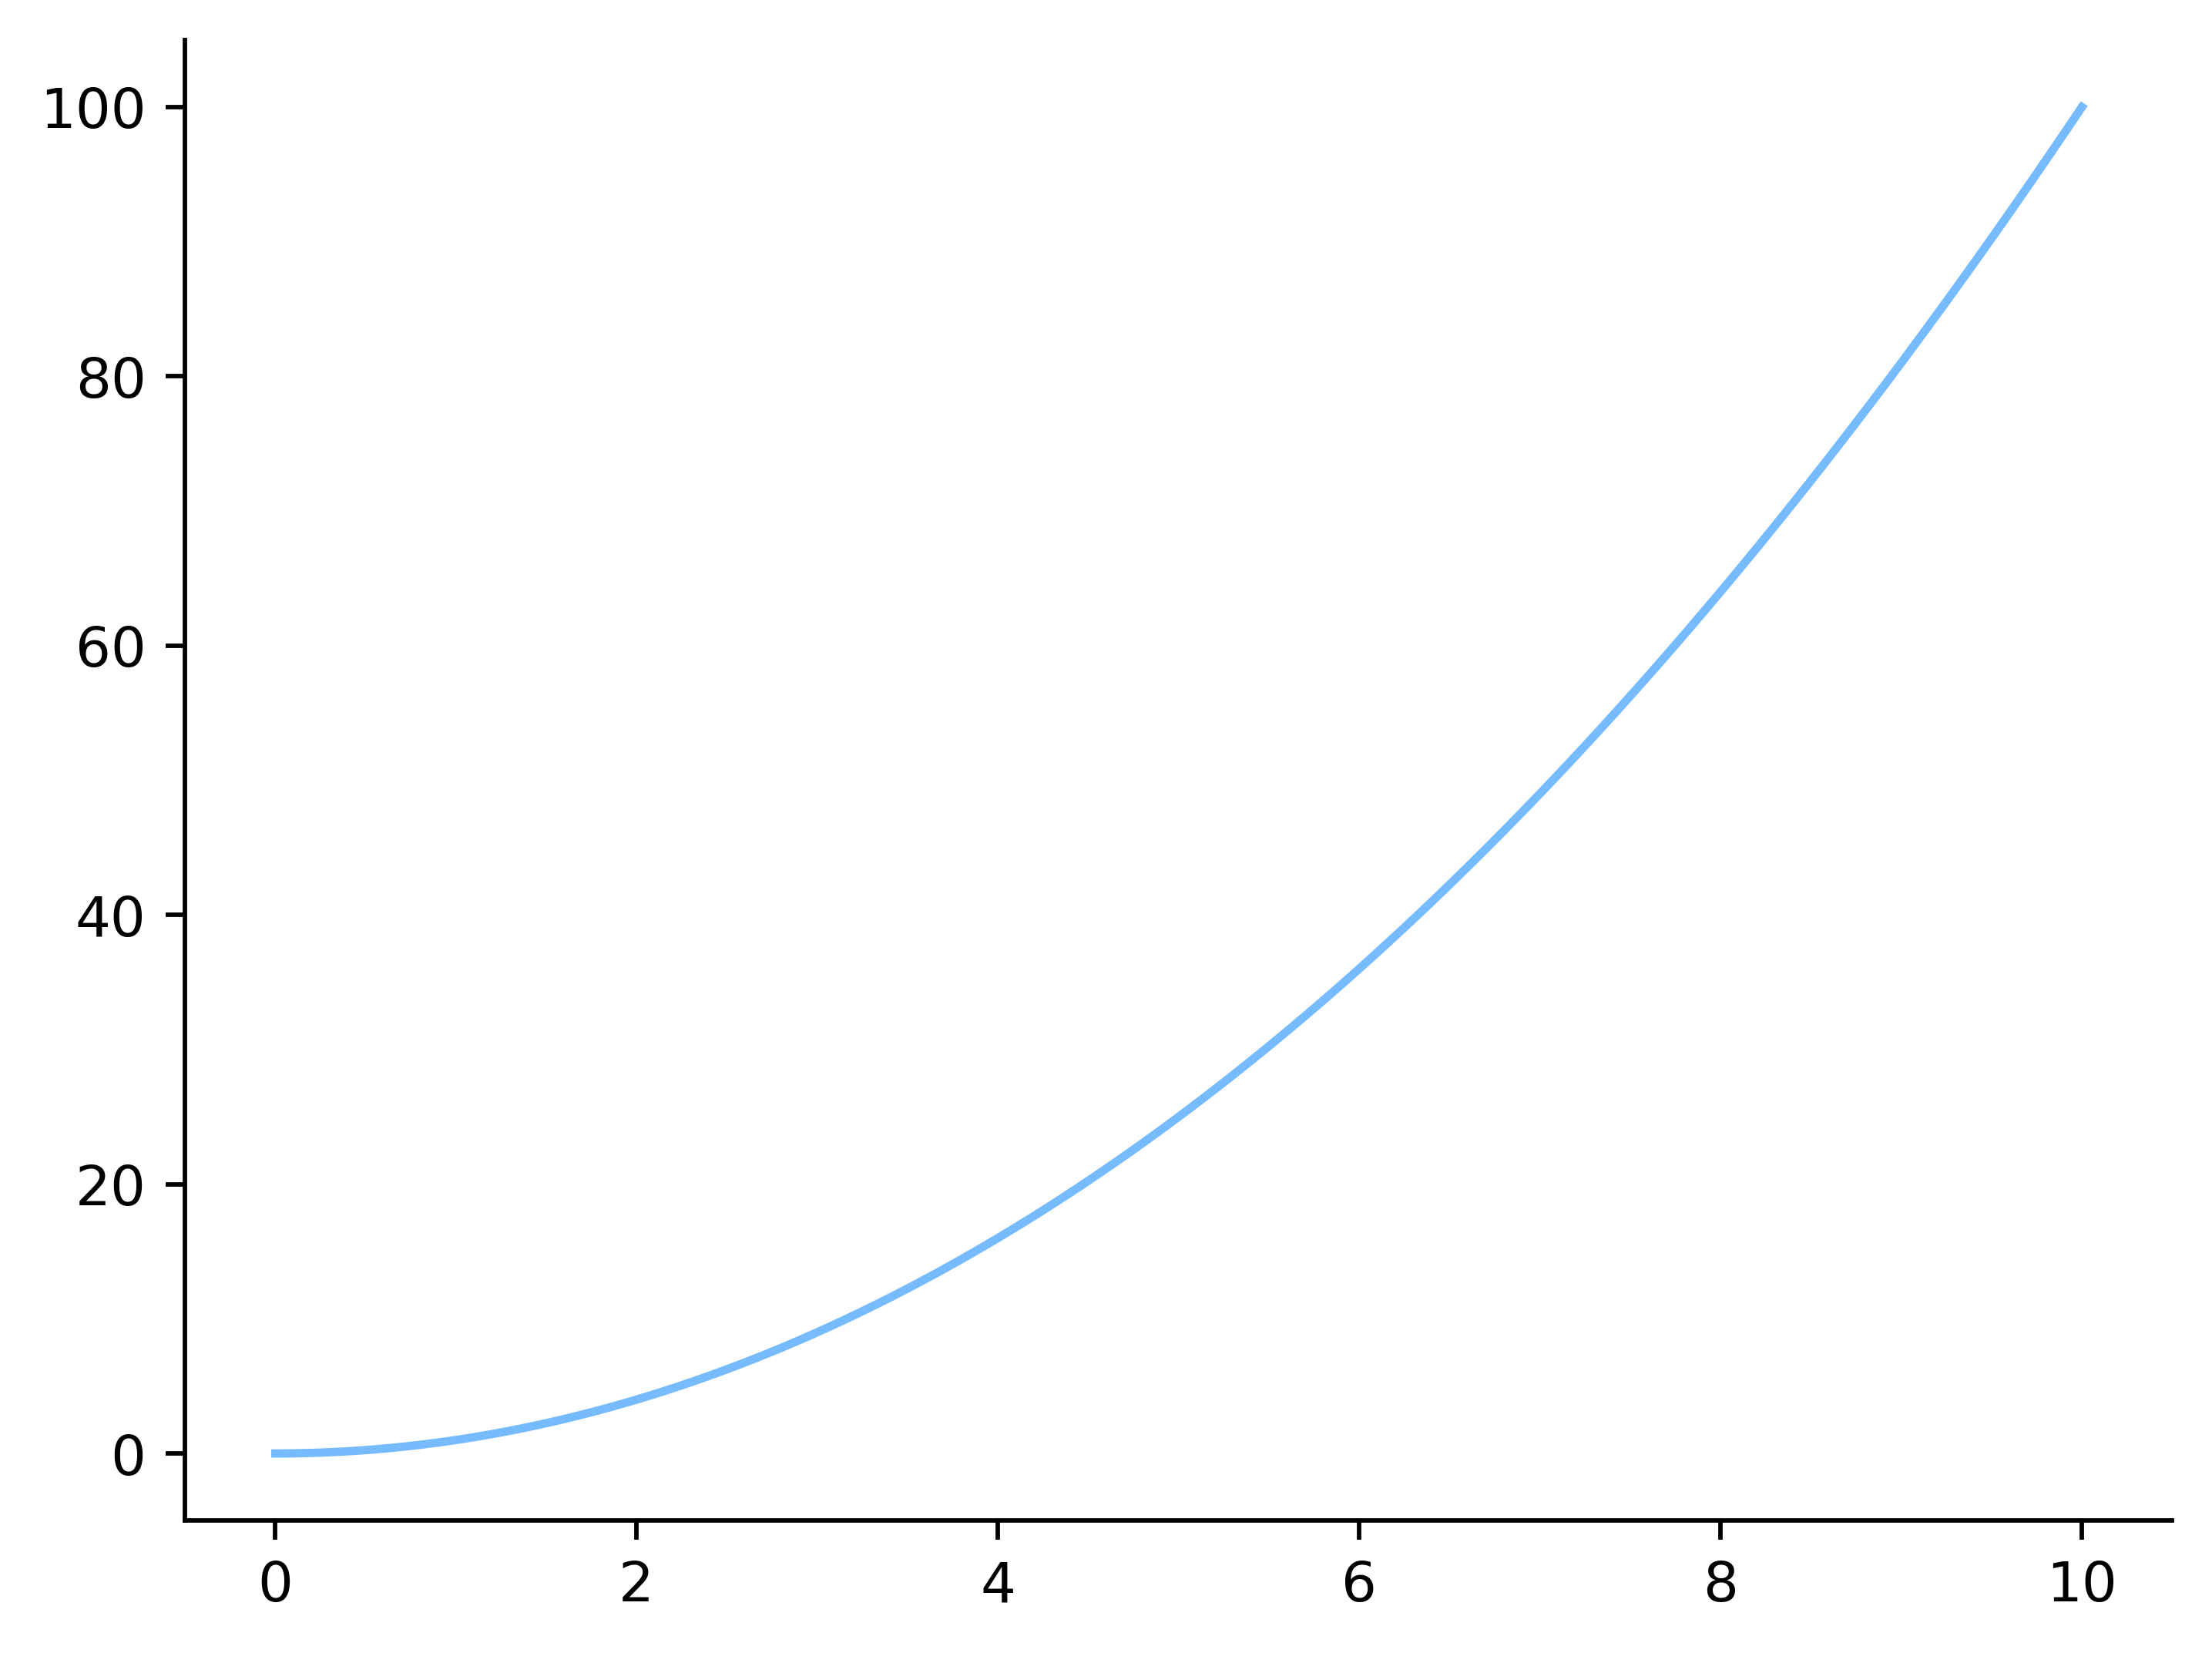

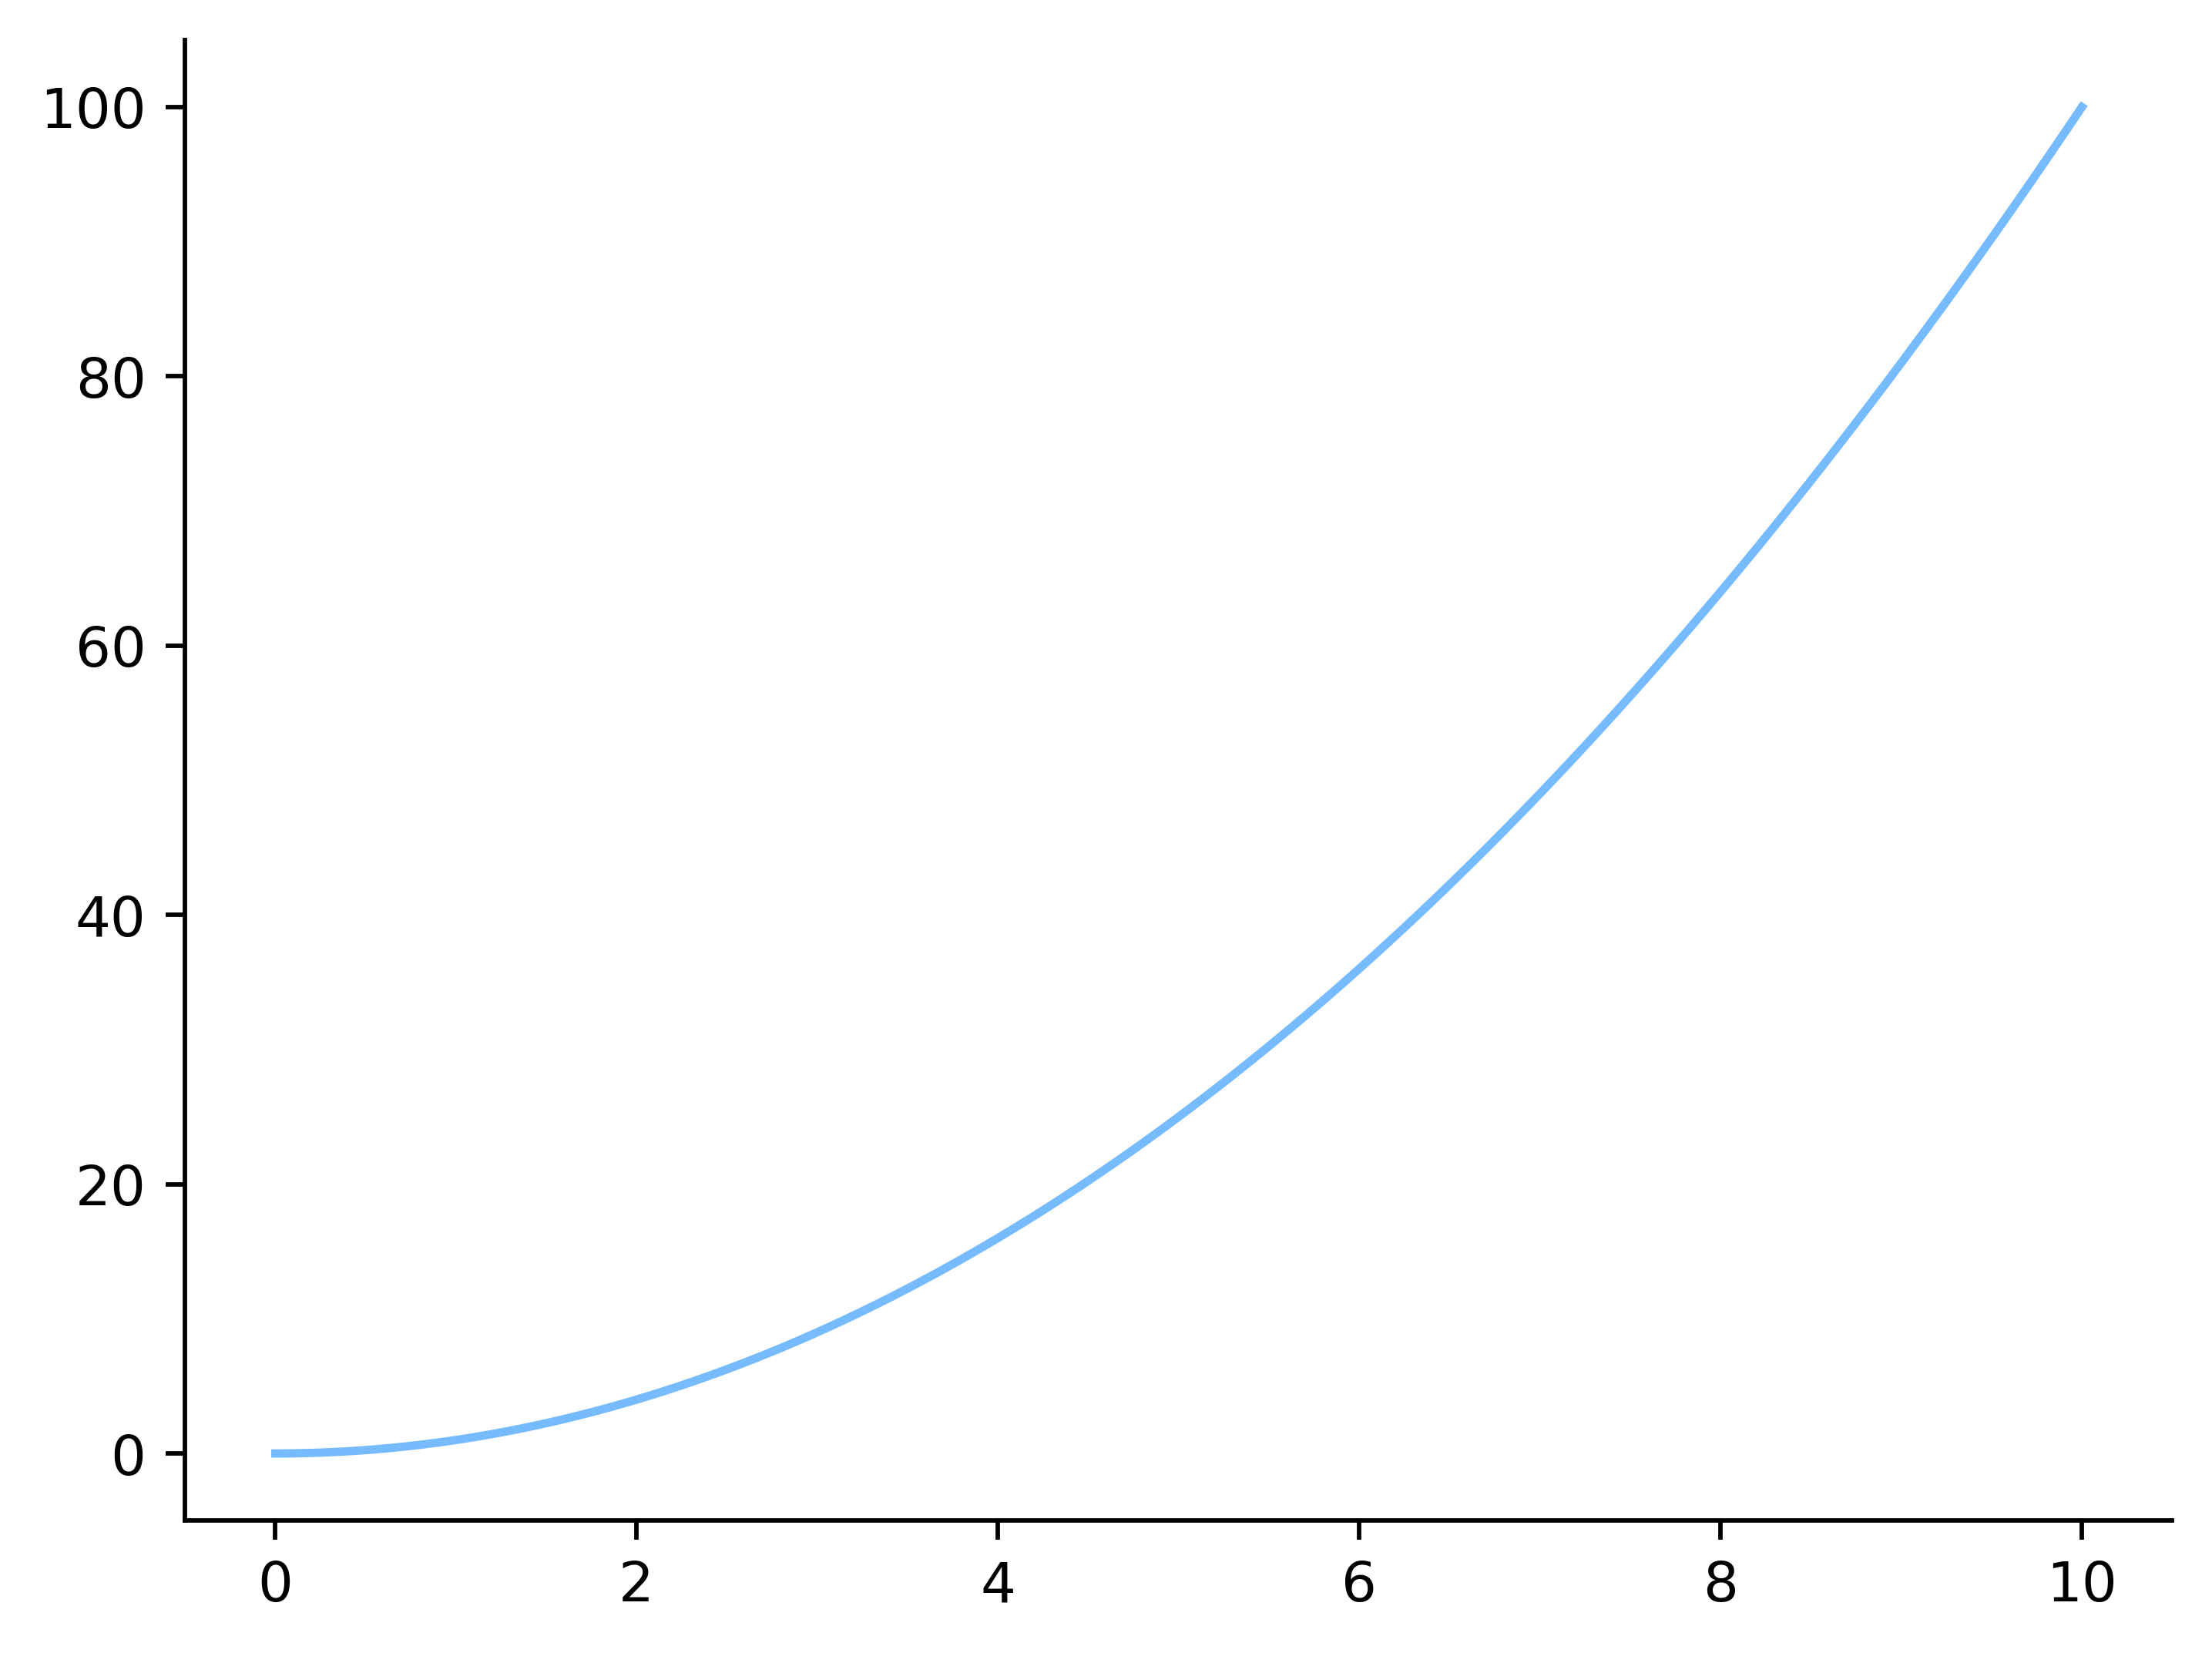

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from myst_nb import glue

fig, ax = plt.subplots()

skewness = np.linspace(0.001, 10, 500)
kurtosis = skewness**2
plt.plot(skewness, kurtosis)
plt.show()

glue("poisson-sk-plot", fig, display=True)

```{glue:figure} poisson-sk-plot
:figwidth: 400pt
:name: "fig:poisson-sk-plot"

Il grafico skewness-curtosi per la famiglia delle distribuzioni di Poisson.
```